# Lasso and Slope estimators

Neste projeto iremos implementar métodos iterativos para achar a solução do seguinte estimador de mínimos quadrados regularizado:

$$
\min_{b\in\mathbb{R}^{p\times1}}f(b)=\frac{1}{2n}\sum_{i=1}^n(y_i-x_i^\top b)^2+\lambda\Vert b\Vert_\sharp, 
$$

onde $(y_1,x_1), \ldots, (y_n,x_n)$ é uma amostra de labels/features em $\mathbb{R}\times\mathbb{R}^p$. Àcima, $\lambda>0$ é um hyper-parâmetro positivo e 

$$
\Vert b\Vert_\sharp := \sum_{j=1}^p\omega[j]b_\sharp[j],
$$

é a *norma Slope* do vetor $b$, onde $\omega\in\mathbb{R}^{p\times1}$ é um vetor de coordenadas positivas não-decrescente e $b_\sharp[1]\ge\ldots,b_\sharp[p]$ simboliza as coordenadas de $b$ postas em ordem não-crescente.  Precisamente, iremos considerar duas opcões:

1. $\omega[j]\equiv1$, 
2. $\omega[j]:=\sqrt{\log(2p/j)}$.

<div hidden>
$\DeclareMathOperator{\sign}{sign}$
$\DeclareMathOperator{\argmin}{argmin}$
</div>

# Soft-Thresholding e ``sortedL1Prox()``

Recorde que o passo de iteração do método gradiente proximal é calcular o *operador proximal* da norma $\lambda\Vert\cdot\Vert_\sharp$:

$$
P(v,\lambda\omega)\in\argmin_{b\in\mathbb{R}^{p\times1}}\left\{
\frac{1}{2}\Vert v - b\Vert_2^2 + \lambda\Vert b\Vert_\sharp
\right\}.
$$

1. Suponha primeiro que $\omega[j]\equiv1$ então $P(v,\lambda\omega)$ tem fórmula explicíta. Dados $\gamma\in\mathbb{R}$, defina

$$
S(\gamma,\lambda):=\sign(\gamma)\cdot\max\{|\gamma|-\lambda,0\}.
$$

Àcima, $\sign(\gamma)$ é o sinal de $\gamma$. Então, para um vetor $v\in\mathbb{R}^{p\times1}$,

$$
P(v,\lambda\omega)=[S(v[1],\lambda) \ldots S(v[p],\lambda)]^\top
$$

2. No caso do item 2, não existe uma fórmula explícita para $P(v,\lambda\omega)$. Mas podemos usar a função ``sortedL1Prox()`` do pacote ``SLOPE`` escrito em R. Veja [SLOPE](https://cran.r-project.org/web/packages/SLOPE/index.html), assim como introduções em [An intro to SLOPE](https://cran.r-project.org/web/packages/SLOPE/vignettes/introduction.html) e [Proximal Operators](https://cran.r-project.org/web/packages/SLOPE/vignettes/prox-algs.html). Em nossa notação, ``sortedL1Prox(v,lambda*omega)`` computa $P(v,\lambda\omega)$ para a sequência $\omega$.

Antes precisaremos criar um código para boter ler a função `sortedL1Prox()` em Python. Para tanto, precisaremos da biblioteca `rpy2`. Para instalá-lo chame `pip install rpy2` no terminal base de sua maquina. Em R, o pacote ``SLOPE`` precisa estar instalado e fazer o chamado ``library(SLOPE)``.

In [424]:
import matplotlib
import numpy as np
import scipy
import seaborn as sns
import matplotlib.pyplot as plt
import numpy.linalg as la

from rpy2 import robjects
from rpy2.robjects.packages import importr

In [425]:
def sortedL1Prox(v,seq):
    '''
    Função que toma (v,seq) e retorna P(v,seq).
    '''
    # R representation in Python of (v,seq):
    r_var = robjects.vectors.FloatVector(np.hstack((v,seq)))
    # Python function to call R function sortedL1Prox()
    func = robjects.r(
    '''
    library(SLOPE)
    function(v,seq) sortedL1Prox(v,seq)
    '''
    )
    # Calling Python function sortedL1Prox using R representation r_var:
    return np.asarray(func(r_var[0:len(r_var)//2], r_var[len(r_var)//2:]))

In [426]:
#Exemplo:
v = 90.0*np.arange(10)
omega = np.ones(10)
lambd = 2.5
seq = lambd*omega
v.shape, omega.shape

((10,), (10,))

In [427]:
sortedL1Prox(v,seq)

array([  0. ,  87.5, 177.5, 267.5, 357.5, 447.5, 537.5, 627.5, 717.5,
       807.5])

# Exercício 1: Gerando dados

1. Construa uma função ``data_genP(p,s,b_mag)`` que toma $p$, $s\in[p]$ e número positivo ``b_mag`` e retorna vetor $p$-dimensional cujas $s$-ézimas primeiras coordenadas são $b_{\text{mag}}$ e as outras são zero.

In [428]:
def data_genP(p,s,b_mag):
    b_true = np.zeros(p)
    b_true[:s] = b_mag
    return b_true
    

In [429]:
#Exemplo:
p=100
s=10
b_mag=2
b_true = data_genP(p,s,b_mag)
b_true

array([2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

2. Construa uma função ``data_genXe(n,p,b_true,sd)`` que toma $n$, $p$, $b_{\text{true}}$ e um número positivo ``sd`` e constrói uma matriz de dados ``X`` $n\times p$ cujas linhas são vetores $x_i^\top$ normais padrão $p$-dimensionais independentes e o vetor ``y`` de dimensão $n$ cujas coordenadas satisfazem

$$
y_i = x_i^\top b_{\text{true}} + \text{sd}\cdot\epsilon_i,
$$
onde $\{\epsilon_i\}_{i=1}^n$ é uma sequência iid de normais padrão. 

In [430]:
def data_genXe(n, p, b_true, sd, sigma=1):
    X = np.random.normal(scale = sigma, size = n * p).reshape(n,p)
    e = np.random.normal( size=n)
    y = X @ b_true + sd * e
    return X, y


In [431]:
#Exemplo:
sd = 0.1
n = 3000
p = 90

b_true = data_genP(p,s,b_mag)
X,y = data_genXe(n,p,b_true,sd)
X,y

(array([[-1.14249095, -1.08921308,  0.17805181, ...,  0.32135174,
         -0.87965786, -0.83346509],
        [ 0.15610846, -1.38149734,  1.10290889, ...,  0.5756712 ,
          0.14145477,  0.88890041],
        [-1.04401265, -1.23723143, -0.54987435, ..., -0.73194592,
          0.97082439,  0.12554934],
        ...,
        [-0.15655853, -0.13286874, -0.99607445, ..., -1.18692703,
          0.75534314, -0.05419566],
        [-0.36647619, -1.16198161, -0.47853795, ...,  0.74236717,
         -1.14126635,  1.28636884],
        [ 2.73746807,  0.03922669, -1.0627121 , ...,  1.12963676,
          0.87822716,  1.45427023]], shape=(3000, 90)),
 array([ -4.25625316,  -5.06341108, -16.00974628, ...,   3.79144281,
          4.66922471,   2.15020311], shape=(3000,)))

# Exercício 2: 

Vamos usar o método gradiente proximal para resolver o problema àcima:

\begin{align*}
w_{k+1} &:= b_k - \frac{1}{L}\nabla f(b_k),\\
b_{k+1} &:= P\left(w_{k+1},\frac{\lambda}{L}\omega\right).
\end{align*}

Construa uma função ``linear_reg(n,p,SlopeB,X,y,L,lambd,b0,t_final)`` onde, $1/L$ é o passo, ``lambd`` ($=\lambda$) é o fator de penalização, ``b0`` é o ponto inicial, a variável ``t_final`` é o número de iterações e:

1. a variável Booleana ``SlopeB`` vale ``False`` se a sequêndia $\omega[j]\equiv1$.
2. a variável Booleana ``SlopeB`` vale ``True`` se $\omega[j]=\sqrt{\log(2p/j)}$. 

A função deve retornar a sequência $k\mapsto\frac{1}{2n}\sum_{i=1}^n(y_i-x_i^\top b_k)^2$ e o último iterado $b_{tfinal}$. Use penalização

$$
\lambda = \text{sd}\sqrt{\frac{\log p}{n}}, 
$$

e passo $1/L$ com

$$
L = A\lambda_{\max}\left(\frac{X^\top X}{n}\right),
$$ 
para algum ajuste fino $A>0$. 

In [432]:
def soft_thresholding(gamma, lambda_val):
    """
    Função S(gamma, lambda) = sign(gamma) * max(|gamma| - lambda, 0).
    Aplica elemento a elemento.
    """
    return np.sign(gamma) * np.maximum(np.abs(gamma) - lambda_val, 0)

def linear_reg(n,p,SlopB, X, y, L, lambd, b0, t_final):
    b_k = b0.copy()
    erros = []

    if SlopB:
        j = np.arange(1, p + 1)
        omega = np.sqrt(np.log(2 * p / j))
    else:
        omega = np.ones(p)

    for k in range(1, t_final):
        w = b_k - (1 / L) * (1 / n) * X.T @ (X @ b_k - y) 
        if not SlopB:
            b_k = soft_thresholding(w, lambd / L * omega)
        else:
            b_k = sortedL1Prox(w, lambd / L * omega)
            
        erros.append( 1 / (2*n)*(y - X @ b_k).T @ (y - X @ b_k))
    
    return erros, b_k
    

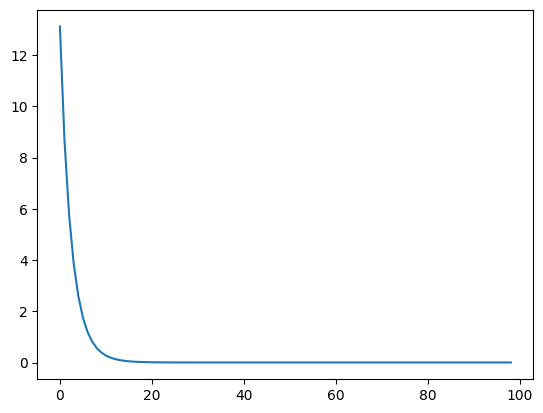

In [433]:
#Exemplo:
b0 = np.zeros(p).T
t_final = 100
SlopeB = True
A = 4
L = A*np.max(la.eigvalsh(X.T @ X / X.shape[0]))
lambd = sd*np.sqrt(np.log(p)/n)      

f1 = linear_reg(n,p,SlopeB,X,y,L,lambd,b0,t_final)
plt.plot(f1[0])

# Pergunta: 

Varie $A$. O que acontece se $A$ for muito pequeno? Alguma intuição?

## **Resposta:**

Quando **$A$** é muito pequeno o algoritmo tende a divergir, como mostrado no plot a seguir:

C:\Users\Matheus Pinto\AppData\Local\Temp\ipykernel_18284\2440177475.py:25: RuntimeWarning: overflow encountered in matmul
  erros.append( 1 / (2*n)*(y - X @ b_k).T @ (y - X @ b_k))


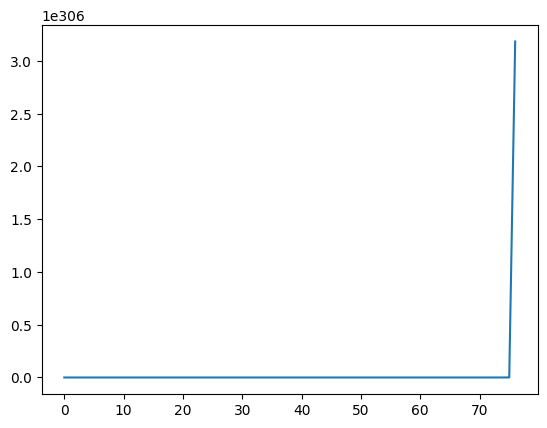

In [434]:
b0 = np.zeros(p).T
t_final = 100
SlopeB = True
A = 0.01
L = A*np.max(la.eigvalsh(X.T @ X / X.shape[0]))
lambd = sd*np.sqrt(np.log(p)/n)      

f1 = linear_reg(n,p,SlopeB,X,y,L,lambd,b0,t_final)
plt.plot(f1[0])

A intuição por trás deste fenômeno e pode ser explicada desta forma: \
- A constante de Lipschitz é calculada desta forma:  **$L = A\lambda_{\max}\left(\frac{X^\top X}{n}\right)$**
- Perceba que quanto menor o valor de **$A$**, menor será o valor da constante. Portanto o passo será muito maior.
- Logo, quando **$A$** é muito pequeno, o meu passo se torna absurdamente grande, portanto, o "ajuste" que o gradiente faz a cada interação se tornará cada vez pior, ocorrendo a divergência do algoritmo.

# Exercício 3: 

Agora, vamos usar o método gradiente proximal acelerado: iniciando de `b0=z0` e $t_0=1$:

\begin{align*}
z_{k+1}&:= P\left(
b_k - (1/L)\nabla f(b_k), \frac{\lambda}{L}\omega
\right),\\
t_{k+1} &:= \frac{1+\sqrt{1+4t_k^2}}{2},\\
b_{k+1} &:= z_{k+1} + \frac{t_{k}-1}{t_{k+1}}(z_{k+1} - z_{k}).
\end{align*}

Construa uma função ``linear_reg_acc(n,p,SlopeB,X,y,L,lambd,b0,t_final)`` onde, $1/L$ é o passo, ``lambd`` ($=\lambda$) é o fator de penalização, ``b0`` é o ponto inicial, a variável ``t_final`` é o número de iterações e:

1. a variável Booleana ``SlopeB`` vale ``False`` se a sequêndia $\omega[j]\equiv1$.
2. a variável Booleana ``SlopeB`` vale ``True`` se $\omega[j]=\sqrt{\log(2p/j)}$. 

A função deve retornar a sequência $k\mapsto\frac{1}{2n}\sum_{i=1}^n(y_i-x_i^\top b_k)^2$ e o último iterado $b_{\text{t_final}}$. Use penalização

$$
\lambda = \text{sd}\sqrt{\frac{\log p}{n}}.
$$

In [435]:
def linear_reg_acc(n,p,SlopeB,X,y,L,lambd,b0,t_final):
    b_k = b0.copy()
    z_k = b0.copy()
    t_k = 1
    erros = []

    if SlopeB:
        j = np.arange(1, p + 1)
        omega = np.sqrt(np.log(2 * p / j))
    else:
        omega = np.ones(p)

    for k in range(1, t_final):
        w = b_k - (1 / L) * (1 / n) * X.T @ (X @ b_k - y)
        if not SlopeB:
            z_k_1 = soft_thresholding(w, lambd / L * omega) 
        else:
            z_k_1 = sortedL1Prox(w, lambd / L * omega)

        t_k_1 = (1 + np.sqrt(1 + 4 * t_k ** 2)) / 2
        b_k = z_k_1 + (t_k - 1) / t_k_1 * (z_k_1 - z_k)

        z_k = z_k_1.copy()
        t_k = t_k_1
        erros.append( 1 / (2*n)*(y - X @ b_k).T @ (y - X @ b_k))
    
    return erros, b_k

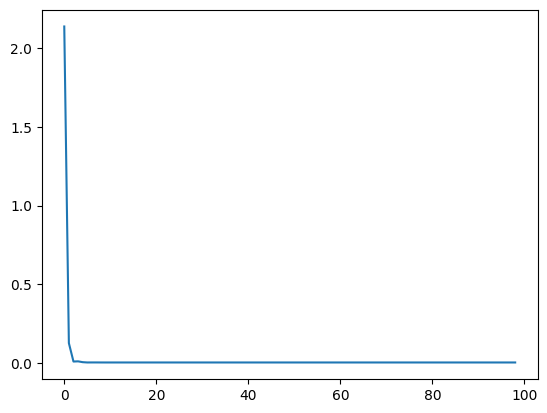

In [436]:
#Exemplo:
b0 = np.zeros(p).T
t_final = 100
SlopeB = False
A = 1.1
L = A * np.max(la.eigvalsh(X.T @ X / X.shape[0]))
lambd = sd*np.sqrt(np.log(p)/n)      

f2 = linear_reg_acc(n,p,SlopeB,X,y,L,lambd,b0,t_final)
plt.plot(f2[0])

# Exercício 4: 

Implemente num mesmo gráfico os erros $k\mapsto\frac{1}{2n}\sum_{i=1}^n(y_i-x_i^\top b_k)^2$ de cada método em função no número de iterações.

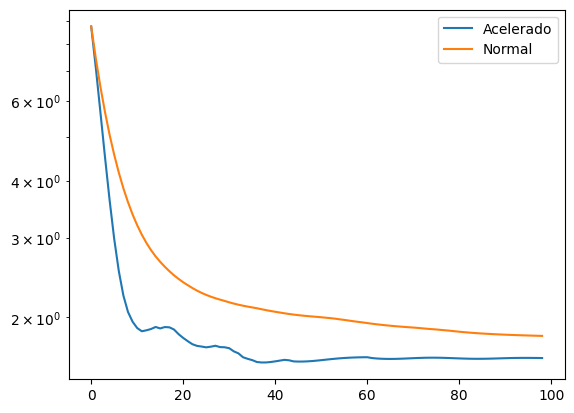

In [437]:
#Exemplo:
sd = 0.9
n = 5
p = 100 

b_true = data_genP(p,s,b_mag)
X,y = data_genXe(n,p,b_true,sd)

def comparacao(X, y, title=None):
    b0 = np.zeros(p).T
    t_final = 100
    SlopeB = True
    A = 5
    L = A * np.max(la.eigvalsh(X.T @ X / X.shape[0]))
    lambd = sd*np.sqrt(np.log(p)/n)      

    f2 = linear_reg_acc(n,p,SlopeB,X,y,L,lambd,b0,t_final)
    plt.plot(f2[0], label ="Acelerado")     

    f1 = linear_reg(n,p,SlopeB,X,y,L,lambd,b0,t_final)
    plt.plot(f1[0], label = "Normal")
    

    plt.legend()
    plt.yscale("log")
    plt.title(title)
    plt.show()

comparacao(X, y)
    

# Exercício 5:

Refaça os exercícios com $\sigma=1$ e $\sigma=10$. Há alguma diferença quando $\sigma=10$? Tem alguma intuição de porque isso acontece?

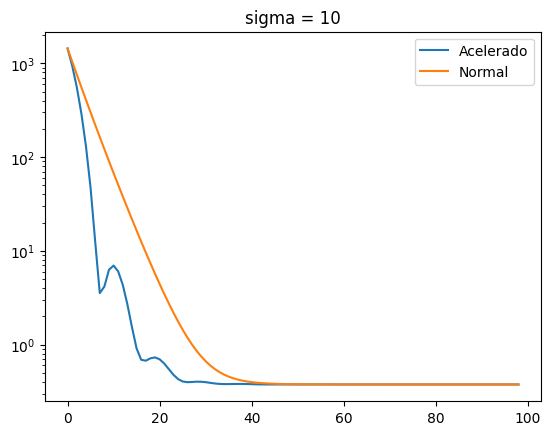

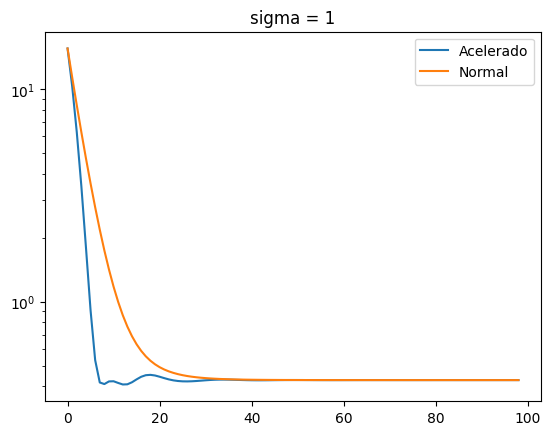

In [438]:
sd = 0.9
n = 3000
p = int(0.9 * 100) 

b_true = data_genP(p,s,b_mag)
X,y = data_genXe(n,p,b_true,sd, sigma=10)

comparacao(X, y, title=f"sigma = 10")
    
X,y = data_genXe(n,p,b_true,sd, sigma=1)
comparacao(X, y, title="sigma = 1")

## **Resposta:**

Acontece que quando aumentamos o valor de **$sigma$** nós estamos alterando diretamente o valor da variável **$L$**, pois ela depende diretamente de **$X$** para ser calculada. Com o aumento de **$L$** nós estamos fazendo com que o passo do algortimo , **$\frac{1}{L}$**, seja muito menor, ou seja, o algoritmo tende a ter uma convergência mais lenta.